In [14]:
import numpy as np
import pandas as pd

matrix = np.loadtxt("/home/dsemchin/data/iit_connectivity_matrix/IIT_connectivity_matrix.txt")

names = [
    "ctx-lh-bankssts", "ctx-lh-caudalanteriorcingulate", "ctx-lh-caudalmiddlefrontal",
    "ctx-lh-cuneus", "ctx-lh-entorhinal", "ctx-lh-fusiform", "ctx-lh-inferiorparietal",
    "ctx-lh-inferiortemporal", "ctx-lh-isthmuscingulate", "ctx-lh-lateraloccipital",
    "ctx-lh-lateralorbitofrontal", "ctx-lh-lingual", "ctx-lh-medialorbitofrontal",
    "ctx-lh-middletemporal", "ctx-lh-parahippocampal", "ctx-lh-paracentral",
    "ctx-lh-parsopercularis", "ctx-lh-parsorbitalis", "ctx-lh-parstriangularis",
    "ctx-lh-pericalcarine", "ctx-lh-postcentral", "ctx-lh-posteriorcingulate",
    "ctx-lh-precentral", "ctx-lh-precuneus", "ctx-lh-rostralanteriorcingulate",
    "ctx-lh-rostralmiddlefrontal", "ctx-lh-superiorfrontal", "ctx-lh-superiorparietal",
    "ctx-lh-superiortemporal", "ctx-lh-supramarginal", "ctx-lh-frontalpole",
    "ctx-lh-temporalpole", "ctx-lh-transversetemporal", "ctx-lh-insula",
    "Left-Cerebellum-Cortex",
    "Left-Thalamus-Proper", "Left-Caudate", "Left-Putamen", "Left-Pallidum",
    "Left-Hippocampus", "Left-Amygdala", "Left-Accumbens-area",
    "Right-Thalamus-Proper", "Right-Caudate", "Right-Putamen", "Right-Pallidum",
    "Right-Hippocampus", "Right-Amygdala", "Right-Accumbens-area",
    "ctx-rh-bankssts", "ctx-rh-caudalanteriorcingulate", "ctx-rh-caudalmiddlefrontal",
    "ctx-rh-cuneus", "ctx-rh-entorhinal", "ctx-rh-fusiform", "ctx-rh-inferiorparietal",
    "ctx-rh-inferiortemporal", "ctx-rh-isthmuscingulate", "ctx-rh-lateraloccipital",
    "ctx-rh-lateralorbitofrontal", "ctx-rh-lingual", "ctx-rh-medialorbitofrontal",
    "ctx-rh-middletemporal", "ctx-rh-parahippocampal", "ctx-rh-paracentral",
    "ctx-rh-parsopercularis", "ctx-rh-parsorbitalis", "ctx-rh-parstriangularis",
    "ctx-rh-pericalcarine", "ctx-rh-postcentral", "ctx-rh-posteriorcingulate",
    "ctx-rh-precentral", "ctx-rh-precuneus", "ctx-rh-rostralanteriorcingulate",
    "ctx-rh-rostralmiddlefrontal", "ctx-rh-superiorfrontal", "ctx-rh-superiorparietal",
    "ctx-rh-superiortemporal", "ctx-rh-supramarginal", "ctx-rh-frontalpole",
    "ctx-rh-temporalpole", "ctx-rh-transversetemporal", "ctx-rh-insula",
    "Right-Cerebellum-Cortex",
    "Axial-section-through-medulla", "Fornix-body", "Left-optic-tract", "Right-optic-tract",
]
assert matrix.shape == (88, 88) == (len(names), len(names))

In [15]:
def align_connectivity(data_cols, matrix, names):
    """
    data_cols : your PPMI column names, in the order you want (e.g. df.columns order)
    matrix    : connectivity matrix, NxN, rows/cols in the same order as `names`
    names     : atlas region names, length N, matching matrix's row/col order

    Returns (aligned_matrix, matched_cols, unmatched_cols).
    aligned_matrix[i, j] corresponds to matched_cols[i] vs matched_cols[j].
    """
    name_to_idx = {name: i for i, name in enumerate(names)}

    def ppmi_to_atlas(col):
        base = col
        for suffix in ("_Z_predict",):
            if base.endswith(suffix):
                base = base[: -len(suffix)]
                break
        if base.startswith("L_"):
            return "ctx-lh-" + base[2:]
        if base.startswith("R_"):
            return "ctx-rh-" + base[2:]
        return base  # subcortical names already match verbatim (Left-Putamen, etc.)

    matched_cols, matched_idx, unmatched_cols = [], [], []
    for col in data_cols:
        atlas_name = ppmi_to_atlas(col)
        if atlas_name in name_to_idx:
            matched_cols.append(col)
            matched_idx.append(name_to_idx[atlas_name])
        else:
            unmatched_cols.append(col)

    aligned = matrix[np.ix_(matched_idx, matched_idx)]
    np.fill_diagonal(aligned, 0)
    return aligned, matched_cols, unmatched_cols

In [16]:
ppmi_df = pd.read_csv('/home/dsemchin/data/PPMI_deviation_scores.csv')
data_cols = [col for col in ppmi_df.columns if 'Z_predict' in col]

K_aligned, matched_cols, unmatched_cols = align_connectivity(data_cols, matrix, names)

print("data_cols count:", len(data_cols))
print("aligned K shape:", K_aligned.shape)
print("\nUNMATCHED (no atlas node -- expect ICV + both ventricles):")
for c in unmatched_cols:
    print(" ", c)

print("\nFirst 10 matched cols (-> K rows/cols 0-9):")
for i, c in enumerate(matched_cols[:10]):
    print(f"{i}: {c}")

print("\nLast 10 matched cols:")
for i, c in enumerate(matched_cols[-10:], start=len(matched_cols) - 10):
    print(f"{i}: {c}")

data_cols count: 85
aligned K shape: (82, 82)

UNMATCHED (no atlas node -- expect ICV + both ventricles):
  EstimatedTotalIntraCranialVol_Z_predict
  Right-Lateral-Ventricle_Z_predict
  Left-Lateral-Ventricle_Z_predict

First 10 matched cols (-> K rows/cols 0-9):
0: L_precuneus_Z_predict
1: R_parahippocampal_Z_predict
2: L_inferiortemporal_Z_predict
3: R_parsopercularis_Z_predict
4: L_inferiorparietal_Z_predict
5: L_entorhinal_Z_predict
6: R_cuneus_Z_predict
7: L_temporalpole_Z_predict
8: L_middletemporal_Z_predict
9: R_inferiorparietal_Z_predict

Last 10 matched cols:
72: Right-Pallidum_Z_predict
73: Left-Hippocampus_Z_predict
74: Left-Caudate_Z_predict
75: Left-Pallidum_Z_predict
76: Right-Accumbens-area_Z_predict
77: Left-Accumbens-area_Z_predict
78: Left-Thalamus-Proper_Z_predict
79: Right-Amygdala_Z_predict
80: Right-Putamen_Z_predict
81: Right-Thalamus-Proper_Z_predict


In [17]:
name_to_idx = {n: i for i, n in enumerate(names)}
for col in data_cols:
    atlas_name = col
    for suffix in ("_Z_predict",):
        if atlas_name.endswith(suffix):
            atlas_name = atlas_name[: -len(suffix)]
            break
    if atlas_name.startswith("L_"):
        atlas_name = "ctx-lh-" + atlas_name[2:]
    elif atlas_name.startswith("R_"):
        atlas_name = "ctx-rh-" + atlas_name[2:]
    idx = name_to_idx.get(atlas_name, "NO MATCH")
    print(f"{col:45s} -> {atlas_name:35s} -> idx {idx}")
print(len(data_cols))

L_precuneus_Z_predict                         -> ctx-lh-precuneus                    -> idx 23
R_parahippocampal_Z_predict                   -> ctx-rh-parahippocampal              -> idx 63
L_inferiortemporal_Z_predict                  -> ctx-lh-inferiortemporal             -> idx 7
R_parsopercularis_Z_predict                   -> ctx-rh-parsopercularis              -> idx 65
L_inferiorparietal_Z_predict                  -> ctx-lh-inferiorparietal             -> idx 6
L_entorhinal_Z_predict                        -> ctx-lh-entorhinal                   -> idx 4
R_cuneus_Z_predict                            -> ctx-rh-cuneus                       -> idx 52
L_temporalpole_Z_predict                      -> ctx-lh-temporalpole                 -> idx 31
L_middletemporal_Z_predict                    -> ctx-lh-middletemporal               -> idx 13
R_inferiorparietal_Z_predict                  -> ctx-rh-inferiorparietal             -> idx 55
L_parahippocampal_Z_predict                   -> ctx-

In [18]:
import pandas as pd
ppmi_df = pd.read_csv('/home/dsemchin/data/PPMI_deviation_scores.csv')


z_score_cols = [col for col in ppmi_df.columns if 'Z_predict' in col]

for i in range(len(z_score_cols)):
    print(z_score_cols[i])

print(len(z_score_cols))

L_precuneus_Z_predict
R_parahippocampal_Z_predict
L_inferiortemporal_Z_predict
R_parsopercularis_Z_predict
L_inferiorparietal_Z_predict
L_entorhinal_Z_predict
R_cuneus_Z_predict
L_temporalpole_Z_predict
L_middletemporal_Z_predict
R_inferiorparietal_Z_predict
L_parahippocampal_Z_predict
L_isthmuscingulate_Z_predict
L_insula_Z_predict
R_posteriorcingulate_Z_predict
L_supramarginal_Z_predict
L_frontalpole_Z_predict
L_parsorbitalis_Z_predict
R_superiorfrontal_Z_predict
R_superiortemporal_Z_predict
L_cuneus_Z_predict
R_superiorparietal_Z_predict
L_parsopercularis_Z_predict
R_caudalmiddlefrontal_Z_predict
R_transversetemporal_Z_predict
R_parstriangularis_Z_predict
L_rostralanteriorcingulate_Z_predict
R_lingual_Z_predict
R_medialorbitofrontal_Z_predict
R_postcentral_Z_predict
L_superiortemporal_Z_predict
R_inferiortemporal_Z_predict
L_caudalanteriorcingulate_Z_predict
R_entorhinal_Z_predict
L_paracentral_Z_predict
R_rostralmiddlefrontal_Z_predict
L_caudalmiddlefrontal_Z_predict
R_precentral_Z

In [19]:
row_sums = K_aligned.sum(axis=1)
zero_rows = np.where(row_sums == 0)[0]

print(f"Nodes with zero row sum: {len(zero_rows)}")
if len(zero_rows) > 0:
    print("Disconnected (no edges in raw IIT connectome):")
    for idx in zero_rows:
        print(f"  idx {idx}: {matched_cols[idx]}")
else:
    print("None disconnected -- every region has at least one nonzero edge.")

Nodes with zero row sum: 0
None disconnected -- every region has at least one nonzero edge.


In [20]:
TOP_PERCENT = 10  # percent of connections (by streamline count) to keep -- adjust here

def threshold_and_normalize(K, top_percent, names_for_errors=None):
    K = K.copy()
    np.fill_diagonal(K, 0)

    off_diag = ~np.eye(K.shape[0], dtype=bool)
    nonzero_vals = K[off_diag][K[off_diag] > 0]

    cutoff = np.percentile(nonzero_vals, 100 - top_percent)
    K_thresh = np.where(K >= cutoff, K, 0)
    np.fill_diagonal(K_thresh, 0)

    row_sums = K_thresh.sum(axis=1)
    disconnected = np.where(row_sums == 0)[0]
    if len(disconnected) > 0:
        bad = [names_for_errors[i] for i in disconnected] if names_for_errors else disconnected.tolist()
        raise ValueError(f"top_percent={top_percent} disconnects: {bad}. Try a higher top_percent.")

    median_row_sum = np.median(row_sums)
    K_norm = K_thresh / median_row_sum
    np.fill_diagonal(K_norm, 0)

    n_kept = np.count_nonzero(K_thresh)
    n_possible = K.shape[0] * (K.shape[0] - 1)
    print(f"top_percent={top_percent}: kept {n_kept}/{n_possible} off-diagonal entries "
          f"({100*n_kept/n_possible:.1f}%)")
    print(f"median row sum (pre-normalization): {median_row_sum:.2f}")

    return K_thresh, K_norm

K_thresh, K_norm = threshold_and_normalize(K_aligned, TOP_PERCENT, names_for_errors=matched_cols)

row_sums_norm = K_norm.sum(axis=1)
zero_rows_norm = np.where(row_sums_norm == 0)[0]

print(f"Nodes with zero row sum: {len(zero_rows_norm)}")
if len(zero_rows_norm) > 0:
    print("Disconnected (no edges in raw IIT connectome):")
    for idx in zero_rows_norm:
        print(f"  idx {idx}: {matched_cols[idx]}")
else:
    print("None disconnected -- every region has at least one nonzero edge.")



top_percent=10: kept 562/6642 off-diagonal entries (8.5%)
median row sum (pre-normalization): 60710.50
Nodes with zero row sum: 0
None disconnected -- every region has at least one nonzero edge.


In [24]:
percents_to_save = [10, 15, 20]
out_dir = "/home/dsemchin/data/iit_connectivity_matrix"

saved = []
for p in percents_to_save:
    K_thresh_p, K_norm_p = threshold_and_normalize(K_aligned, p, names_for_errors=matched_cols)

    npy_path = f"{out_dir}/K_82_top{p}_normalized.npy"
    csv_path = f"{out_dir}/K_82_top{p}_normalized.csv"

    np.save(npy_path, K_norm_p)
    pd.DataFrame(K_norm_p, index=matched_cols, columns=matched_cols).to_csv(csv_path)

    n_edges = np.count_nonzero(K_thresh_p) // 2
    saved.append((p, n_edges, npy_path, csv_path))
    print(f"top {p}%: {n_edges} edges, saved -> {npy_path}")

print("\nDone. Saved files:")
for p, n_edges, npy_path, csv_path in saved:
    print(f"  top{p}: {npy_path}")
    print(f"         {csv_path}")

top_percent=10: kept 562/6642 off-diagonal entries (8.5%)
median row sum (pre-normalization): 60710.50
top 10%: 281 edges, saved -> /home/dsemchin/data/iit_connectivity_matrix/K_82_top10_normalized.npy
top_percent=15: kept 842/6642 off-diagonal entries (12.7%)
median row sum (pre-normalization): 67223.50
top 15%: 421 edges, saved -> /home/dsemchin/data/iit_connectivity_matrix/K_82_top15_normalized.npy
top_percent=20: kept 1122/6642 off-diagonal entries (16.9%)
median row sum (pre-normalization): 73985.50
top 20%: 561 edges, saved -> /home/dsemchin/data/iit_connectivity_matrix/K_82_top20_normalized.npy

Done. Saved files:
  top10: /home/dsemchin/data/iit_connectivity_matrix/K_82_top10_normalized.npy
         /home/dsemchin/data/iit_connectivity_matrix/K_82_top10_normalized.csv
  top15: /home/dsemchin/data/iit_connectivity_matrix/K_82_top15_normalized.npy
         /home/dsemchin/data/iit_connectivity_matrix/K_82_top15_normalized.csv
  top20: /home/dsemchin/data/iit_connectivity_matrix/K_

top_percent=10: kept 562/6642 off-diagonal entries (8.5%)
median row sum (pre-normalization): 60710.50
top_percent=15: kept 842/6642 off-diagonal entries (12.7%)
median row sum (pre-normalization): 67223.50
top_percent=20: kept 1122/6642 off-diagonal entries (16.9%)
median row sum (pre-normalization): 73985.50
=== top 10% ===
  n edges: 281  (8.5% of all possible pairs)
  nonzero edge weights:
count    562.000000
mean       0.177019
std        0.139239
min        0.054406
25%        0.080497
50%        0.129072
75%        0.219797
max        0.901294
  row sums:
count    82.000000
mean      1.213227
std       0.887163
min       0.061456
25%       0.515174
50%       1.000000
75%       1.764621
max       4.059545

=== top 15% ===
  n edges: 421  (12.7% of all possible pairs)
  nonzero edge weights:
count    842.000000
mean       0.118670
std        0.118209
min        0.025735
25%        0.041355
50%        0.072698
75%        0.143462
max        0.813971
  row sums:
count    82.000000
m

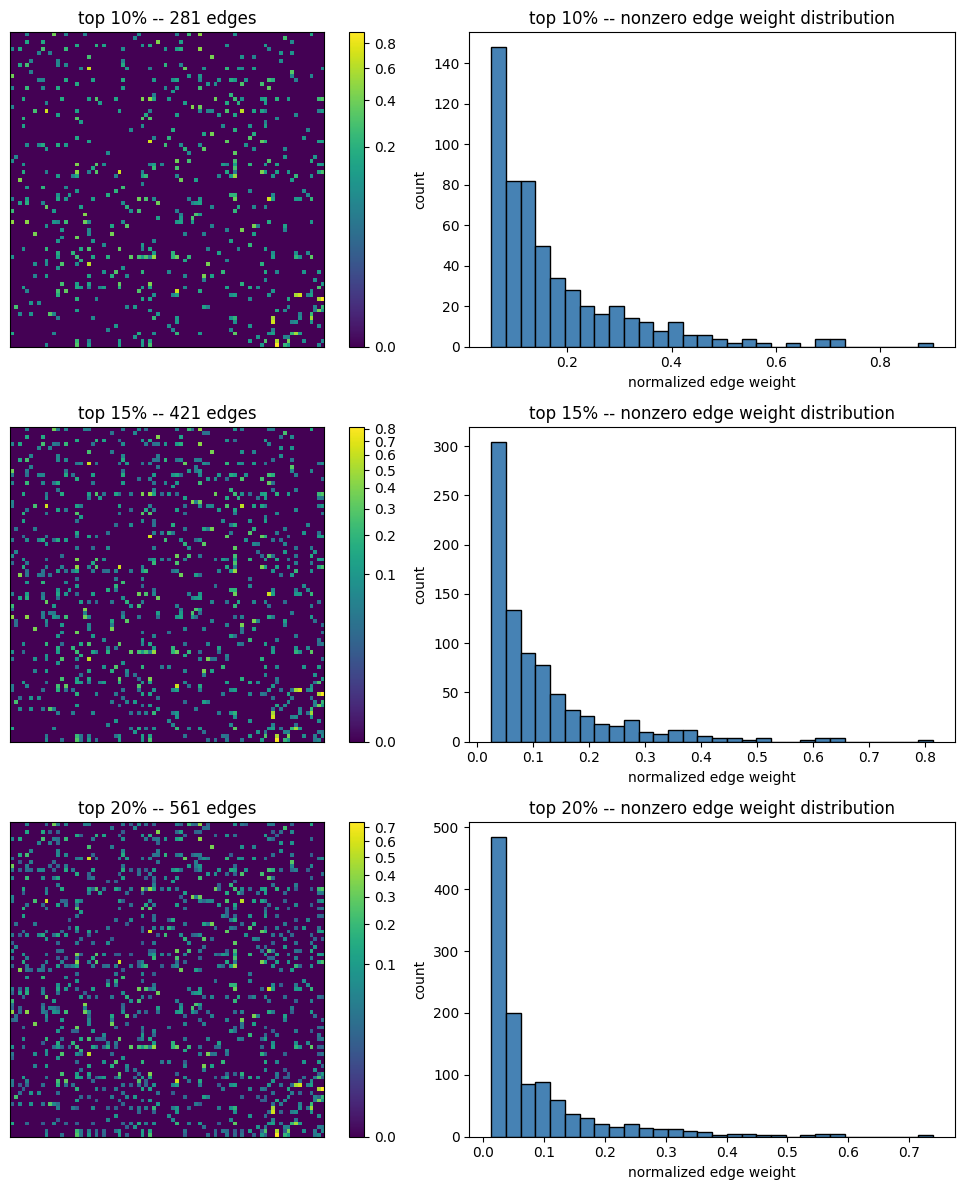

In [22]:
# Cell 1 -- recompute (cheap) and store each threshold's matrix for inspection
percents_to_check = [10, 15, 20]
results = {}

for p in percents_to_check:
    K_thresh_p, K_norm_p = threshold_and_normalize(K_aligned, p, names_for_errors=matched_cols)
    results[p] = {"K_thresh": K_thresh_p, "K_norm": K_norm_p}

# Cell 2 -- descriptive statistics for each threshold
import pandas as pd

for p in percents_to_check:
    K_norm_p = results[p]["K_norm"]
    nz = K_norm_p[K_norm_p > 0]
    row_sums = K_norm_p.sum(axis=1)

    print(f"=== top {p}% ===")
    print(f"  n edges: {nz.size // 2}  ({100 * nz.size / (K_norm_p.size - K_norm_p.shape[0]):.1f}% of all possible pairs)")
    print("  nonzero edge weights:")
    print(pd.Series(nz).describe().to_string())
    print("  row sums:")
    print(pd.Series(row_sums).describe().to_string())
    print()

# Cell 3 -- heatmap + value-distribution histogram for each threshold
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(len(percents_to_check), 2, figsize=(11, 4 * len(percents_to_check)))

for row, p in enumerate(percents_to_check):
    K_norm_p = results[p]["K_norm"]
    nz = K_norm_p[K_norm_p > 0]

    im = axes[row, 0].imshow(K_norm_p, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.3))
    axes[row, 0].set_title(f'top {p}% -- {nz.size // 2} edges')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    plt.colorbar(im, ax=axes[row, 0], fraction=0.046)

    axes[row, 1].hist(nz, bins=30, color='steelblue', edgecolor='black')
    axes[row, 1].set_title(f'top {p}% -- nonzero edge weight distribution')
    axes[row, 1].set_xlabel('normalized edge weight')
    axes[row, 1].set_ylabel('count')

plt.tight_layout()
plt.show()

n cortical regions: 68
n subcortical regions: 14

=== Cortical-Cortical (top 10%) ===
  n edges: 197 / 2278 possible (8.6%)
count    394.000000
mean       0.183020
std        0.134447
min        0.054406
25%        0.082325
50%        0.136681
75%        0.237554
max        0.708461

=== Subcortical-Subcortical (top 10%) ===
  n edges: 20 / 91 possible (22.0%)
count    40.000000
mean      0.262252
std       0.255476
min       0.057173
25%       0.072825
50%       0.126864
75%       0.443082
max       0.901294

=== Cortical-Subcortical, cross (top 10%) ===
  n edges: 64 / 952 possible (6.7%)
count    64.000000
mean      0.131912
std       0.072481
min       0.055509
25%       0.081036
50%       0.108284
75%       0.147837
max       0.343268


/tmp/ipykernel_5870/3724617790.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cc_nz, ss_nz, cs_nz], labels=['cortical-cortical', 'subcortical-subcortical', 'cortical-subcortical'])


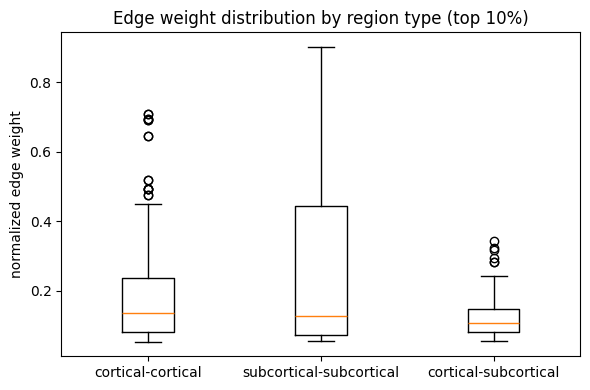

In [23]:
K10 = results[10]["K_norm"]

cortical_idx = [i for i, c in enumerate(matched_cols) if not c.startswith(("Left-", "Right-"))]
subcortical_idx = [i for i, c in enumerate(matched_cols) if c.startswith(("Left-", "Right-"))]

print(f"n cortical regions: {len(cortical_idx)}")
print(f"n subcortical regions: {len(subcortical_idx)}")

cc = K10[np.ix_(cortical_idx, cortical_idx)]       # cortical-cortical block
ss = K10[np.ix_(subcortical_idx, subcortical_idx)] # subcortical-subcortical block
cs = K10[np.ix_(cortical_idx, subcortical_idx)]    # cortical-subcortical cross block (rectangular, no double-count)

cc_nz, ss_nz, cs_nz = cc[cc > 0], ss[ss > 0], cs[cs > 0]

n_cc_possible = len(cortical_idx) * (len(cortical_idx) - 1) // 2
n_ss_possible = len(subcortical_idx) * (len(subcortical_idx) - 1) // 2
n_cs_possible = len(cortical_idx) * len(subcortical_idx)

print("\n=== Cortical-Cortical (top 10%) ===")
print(f"  n edges: {cc_nz.size // 2} / {n_cc_possible} possible ({100 * (cc_nz.size // 2) / n_cc_possible:.1f}%)")
print(pd.Series(cc_nz).describe().to_string())

print("\n=== Subcortical-Subcortical (top 10%) ===")
print(f"  n edges: {ss_nz.size // 2} / {n_ss_possible} possible ({100 * (ss_nz.size // 2) / n_ss_possible:.1f}%)")
print(pd.Series(ss_nz).describe().to_string())

print("\n=== Cortical-Subcortical, cross (top 10%) ===")
print(f"  n edges: {cs_nz.size} / {n_cs_possible} possible ({100 * cs_nz.size / n_cs_possible:.1f}%)")
print(pd.Series(cs_nz).describe().to_string())


fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cc_nz, ss_nz, cs_nz], labels=['cortical-cortical', 'subcortical-subcortical', 'cortical-subcortical'])
ax.set_ylabel('normalized edge weight')
ax.set_title('Edge weight distribution by region type (top 10%)')
plt.tight_layout()
plt.show()